In [3]:
import pandas as pd
import os
import sys

sys.path.append(os.path.abspath(os.path.join("..")))

pancreatic = pd.read_csv("C:/My Work/Python/Machine Learning/Projects/Salivary Biomarker Research/data/processed/panc_filtered.csv")
y = pancreatic[["Cancer"]]
X = pancreatic.drop(columns=["Cancer"])
num_cols = X.select_dtypes(include=["number", "float"]).columns

print(X.columns)
print(y.columns)

Index(['SLC4A8', 'HINT1', 'EME2', 'C4orf27', 'ARIH1', 'PAPPA', 'SEC23IP',
       'KRAS', 'CDKL3', 'TRIM14', 'H2AFX', 'PAGE4', 'USH2A', 'SOCS5',
       'SEC14L5', 'CREB3L2', 'CD7', 'HIST1H3E', 'SMUG1', 'DHRS9', 'HOOK1',
       'WDR48', 'DTX3', 'SEC11C', 'PNPLA8', 'ATAD3B', 'FAHD1', 'ZNF503',
       'TPBGL'],
      dtype='object')
Index(['Cancer'], dtype='object')


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from biotransformers import get_log_transformer
from sklearn.preprocessing import StandardScaler

def create_pipeline(model):
    pipeline = Pipeline([
        ("log_transformer", get_log_transformer()),
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    return pipeline

models = {
    "LogisticRegression": LogisticRegression(),
    "RandomForest": RandomForestClassifier()
}

lr_pipeline = create_pipeline(models["LogisticRegression"])
rf_pipeline = create_pipeline(models["RandomForest"])

In [9]:
lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced"]
}

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 8, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

pipelines = [lr_pipeline, rf_pipeline]
param_grids = [lr_param_grid, rf_param_grid]

In [10]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def specificity_score(y_true, y_pred):
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

scoring = {
    "recall": "recall",
    "specificity": make_scorer(specificity_score)
}

all_results = {}

for grid, model, pipeline in zip(param_grids, models.keys(), pipelines):
    search = GridSearchCV(
        pipeline,
        grid, 
        cv=cv, 
        scoring=scoring, 
        refit="recall",
    )
    search.fit(X, y)
    
    result = pd.DataFrame(search.cv_results_)
    best_rows = result.loc[result["mean_test_recall"].idxmax()]
    all_results[model] = best_rows

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwar

In [13]:
print(all_results["LogisticRegression"]["params"])

{'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


In [14]:
lr_estimator = lr_pipeline.set_params(**all_results["LogisticRegression"]["params"])
rf_estimator = rf_pipeline.set_params(**all_results["RandomForest"]["params"])

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


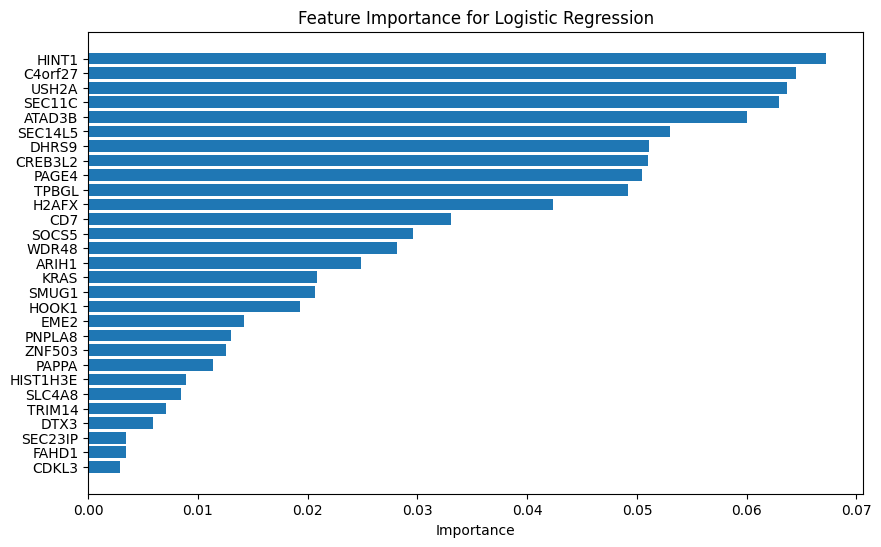

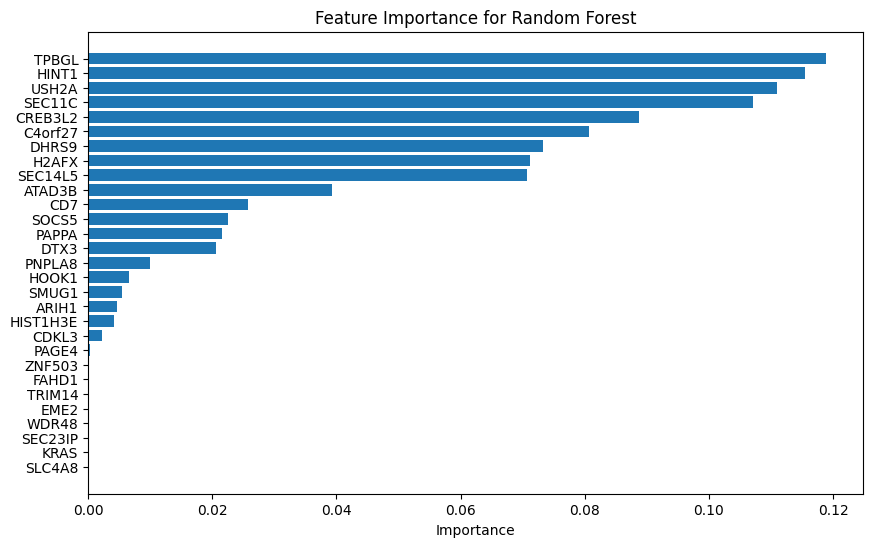

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.base import clone

def create_feat_importance_df(estimator):
    if hasattr(estimator.named_steps["model"], "coef_"):
        importances = np.abs(estimator.named_steps["model"].coef_[0])
    
    elif hasattr(estimator.named_steps["model"], "feature_importances_"):
        importances = estimator.named_steps["model"].feature_importances_
    
    "'CHANGE THIS LATER AFTER FEATURE ENGINEERING'"
    feature_names = X.columns            
    
    return pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

def create_feat_importance_graph(importance_df, model_name):
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.xlabel("Importance")
    plt.title(f"Feature Importance for {model_name}")
    plt.gca().invert_yaxis()
    plt.show()

lr_fitted_feat_import = clone(lr_estimator).fit(X, y)
rf_fitted_feat_import = clone(rf_estimator).fit(X, y)

lr_importance_df = create_feat_importance_df(lr_fitted_feat_import)
rf_importance_df = create_feat_importance_df(rf_fitted_feat_import)

create_feat_importance_graph(lr_importance_df, "Logistic Regression")
create_feat_importance_graph(rf_importance_df, "Random Forest")

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)
